In [1]:
import pandas as pd
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent   # se estiveres em notebooks/
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"

In [3]:
df = pd.read_csv(DATA_DIR / "train.csv")
df.head()
dt= pd.read_csv(DATA_DIR / "test.csv")


In [4]:
categorical_features = ['ChiefComplaint', 'gender', 'NeedFastExecute', 'CriticalStatus', 'PainGrade', 'StuporStatus']
numeric_features = ['age']

target = 'TriageGrade'
features = categorical_features + numeric_features

df = df[categorical_features + numeric_features + [target]]
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

dt = dt[categorical_features + numeric_features + [target]]
dt[numeric_features] = dt[numeric_features].fillna(dt[numeric_features].median())



In [5]:
X_train = df[categorical_features + numeric_features]
y_train = df[target]

X_test = dt[categorical_features + numeric_features]
y_test = dt[target]


In [6]:
print(y_train.value_counts())


TriageGrade
2    52618
3    22308
4    11530
1     6689
5       11
Name: count, dtype: int64


In [7]:
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)


In [8]:
modelo_logreg_multi = Pipeline(
    steps=[
        ('preprocessamento', preprocessor),
        ('classificador', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            solver='lbfgs',
        ))
    ]
)

from sklearn.model_selection import GridSearchCV

param_grid = {
    "classificador__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    modelo_logreg_multi,
    param_grid,
    cv=5,
    scoring="f1_weighted",  # melhor que accuracy para triagem
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)



Best parameters: {'classificador__C': 10}
Best CV score: 0.8862530096852634


In [9]:
best_model = grid.best_estimator_

y_pred_logreg_multi = best_model.predict(X_test)

print("LOGISTIC REGRESSION — MULTI-VARIÁVEL")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg_multi))
print(classification_report(y_test, y_pred_logreg_multi))


LOGISTIC REGRESSION — MULTI-VARIÁVEL
Accuracy: 0.8694878593357521
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2058
           2       1.00      0.98      0.99     16191
           3       0.86      0.66      0.74      6864
           4       0.58      0.68      0.62      3548
           5       0.00      0.33      0.00         3

    accuracy                           0.87     28664
   macro avg       0.69      0.73      0.67     28664
weighted avg       0.91      0.87      0.89     28664



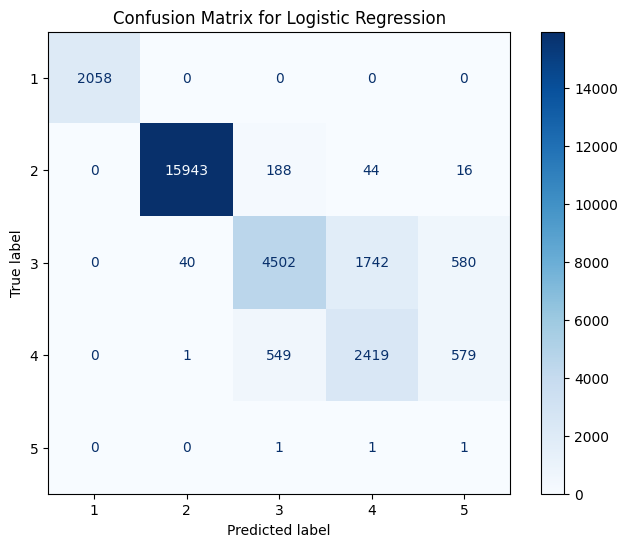

In [10]:
# Plot the Confusion Matrix (Diz quantas pulseiras foram prevista para cada classe)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg_multi, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Logistic Regression")
plt.show()

In [11]:
import os

os.makedirs("models", exist_ok=True)
joblib.dump({
    "model": best_model,
    "features": features
},"models/modelo_logreg_multi_new.joblib")



['models/modelo_logreg_multi_new.joblib']

## MEsmo modelo com pesos

Best parameters: {'classificador__C': 1}
Best CV score: 0.6715771018816672
LOGISTIC REGRESSION — MULTI-VARIÁVEL
Accuracy: 0.8813843148199833
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2058
           2       1.00      0.98      0.99     16191
           3       0.89      0.59      0.71      6864
           4       0.53      0.91      0.67      3548
           5       0.00      0.00      0.00         3

    accuracy                           0.88     28664
   macro avg       0.68      0.70      0.67     28664
weighted avg       0.91      0.88      0.88     28664



C:\Users\biamm\PycharmProjects\ProjetoAI\.venv4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\biamm\PycharmProjects\ProjetoAI\.venv4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\biamm\PycharmProjects\ProjetoAI\.venv4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

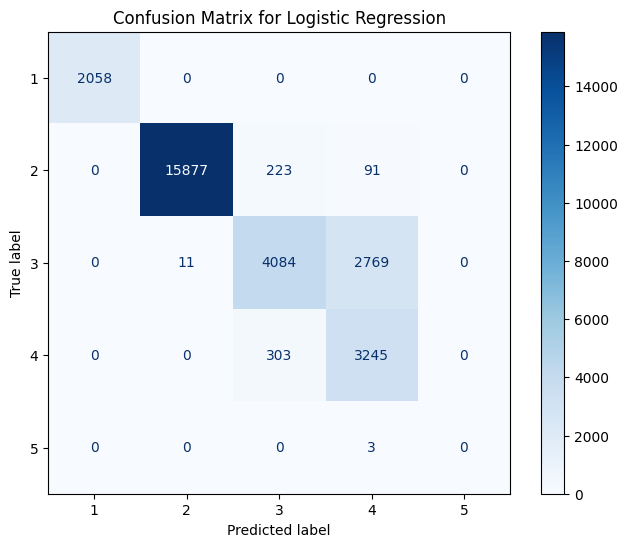

In [12]:
class_weights = {
    1: 1,
    2: 2,
    3: 10,
    4: 50,
    5: 100
}


modelo_logreg_multi2 = Pipeline(
    steps=[
        ('preprocessamento', preprocessor),
        ('classificador', LogisticRegression(
            max_iter=2000,
            class_weight=class_weights,
            solver='lbfgs',
        ))
    ]
)


grid2 = GridSearchCV(
    modelo_logreg_multi2,
    param_grid,
    cv=5,
    scoring="f1_macro",  # melhor que accuracy para triagem
)

grid2.fit(X_train, y_train)

print("Best parameters:", grid2.best_params_)
print("Best CV score:", grid2.best_score_)

best_model2 = grid2.best_estimator_

y_pred_logreg_multi2 = best_model2.predict(X_test)

print("LOGISTIC REGRESSION — MULTI-VARIÁVEL")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg_multi2))
print(classification_report(y_test, y_pred_logreg_multi2))

# Plot the Confusion Matrix (Diz quantas pulseiras foram prevista para cada classe)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg_multi2, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Logistic Regression")
plt.show()

In [13]:

import os

os.makedirs("models", exist_ok=True)
joblib.dump({
    "model": best_model,
    "features": features
}, "models/modelo_logreg_multi_new_weight.joblib")

## MEsmo modelo com pesos

['models/modelo_logreg_multi_new_weight.joblib']